# Session 14: Decision Trees Implementation

## Welcome to Hands-On Decision Trees!

In this notebook, we'll implement decision trees using Python and scikit-learn. You'll learn how to:
- Build decision tree classifiers
- Visualize trees
- Make predictions
- Understand tree structure

### Learning Objectives:
- Implement decision trees with sklearn
- Train and evaluate decision tree models
- Visualize decision trees in multiple ways
- Interpret tree predictions
- Understand decision boundaries

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Decision tree imports
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree, export_text, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris, make_classification, make_moons

# For better visualizations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Simple Classification Example: Play Tennis

Let's start with the classic "Play Tennis" example from the theory session, but this time we'll implement it!

In [2]:
# Create the Play Tennis dataset
tennis_data = pd.DataFrame({
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 
                'Overcast', 'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 
                'Overcast', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 
                    'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 
                 'Normal', 'High'],
    'Windy': ['False', 'True', 'False', 'False', 'False', 'True', 
              'True', 'False', 'False', 'False', 'True', 'True', 
              'False', 'True'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 
             'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 
             'Yes', 'No']
})

print("Tennis Dataset:")
print("="*80)
display(tennis_data)
print("\nTarget Distribution:")
print(tennis_data['Play'].value_counts())

Tennis Dataset:


,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes
5,Rainy,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Sunny,Mild,High,False,No
8,Sunny,Cool,Normal,False,Yes
9,Rainy,Mild,Normal,False,Yes



Target Distribution:
Play
Yes    9
No     5
Name: count, dtype: int64


### 1.1 Manual Tree Construction Logic

Before using sklearn, let's understand how to encode categorical features for the decision tree.

In [3]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

# Make a copy for encoding
tennis_encoded = tennis_data.copy()

# Create label encoders for each feature
encoders = {}
feature_columns = ['Outlook', 'Temperature', 'Humidity', 'Windy']

print("Feature Encoding Mappings:")
print("="*80)

for col in feature_columns:
    encoders[col] = LabelEncoder()
    tennis_encoded[col] = encoders[col].fit_transform(tennis_data[col])
    
    # Print mapping
    print(f"\n{col}:")
    mapping = dict(zip(encoders[col].classes_, encoders[col].transform(encoders[col].classes_)))
    for original, encoded in mapping.items():
        print(f"  {original} → {encoded}")

# Encode target
target_encoder = LabelEncoder()
tennis_encoded['Play'] = target_encoder.fit_transform(tennis_data['Play'])

print(f"\nPlay (Target):")
print(f"  No → 0")
print(f"  Yes → 1")

print("\n" + "="*80)
print("Encoded Dataset:")
print("="*80)
display(tennis_encoded)

Feature Encoding Mappings:

Outlook:
  Overcast → 0
  Rainy → 1
  Sunny → 2

Temperature:
  Cool → 0
  Hot → 1
  Mild → 2

Humidity:
  High → 0
  Normal → 1

Windy:
  False → 0
  True → 1

Play (Target):
  No → 0
  Yes → 1

Encoded Dataset:


,Outlook,Temperature,Humidity,Windy,Play
0,2,1,0,0,0
1,2,1,0,1,0
2,0,1,0,0,1
3,1,2,0,0,1
4,1,0,1,0,1
5,1,0,1,1,0
6,0,0,1,1,1
7,2,2,0,0,0
8,2,0,1,0,1
9,1,2,1,0,1


### 1.2 Building a Decision Tree with sklearn

Now let's build our first decision tree!

In [4]:
# Prepare features and target
X = tennis_encoded[feature_columns]
y = tennis_encoded['Play']

print("Feature Matrix (X):")
print(X.head())
print(f"\nShape: {X.shape}")
print(f"\nTarget Vector (y):")
print(y.values)
print(f"Shape: {y.shape}")

Feature Matrix (X):
   Outlook  Temperature  Humidity  Windy
0        2            1         0      0
1        2            1         0      1
2        0            1         0      0
3        1            2         0      0
4        1            0         1      0

Shape: (14, 4)

Target Vector (y):
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]
Shape: (14,)


In [5]:
# Create and train decision tree
# We'll use entropy (information gain) as criterion
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',      # Use information gain
    random_state=42           # For reproducibility
)

# Train the model
dt_classifier.fit(X, y)

print("Decision Tree Trained Successfully!")
print("\nTree Properties:")
print(f"  Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"  Tree depth: {dt_classifier.get_depth()}")
print(f"  Number of features: {dt_classifier.n_features_in_}")
print(f"  Classes: {target_encoder.inverse_transform(dt_classifier.classes_)}")

Decision Tree Trained Successfully!

Tree Properties:
  Number of leaves: 7
  Tree depth: 4
  Number of features: 4
  Classes: ['No' 'Yes']


### 1.3 Making Predictions

Let's use our trained tree to make predictions!

In [6]:
# Make predictions on training data
y_pred = dt_classifier.predict(X)

# Calculate accuracy
accuracy = accuracy_score(y, y_pred)

print("Predictions vs Actual:")
print("="*80)

results_df = pd.DataFrame({
    'Actual': target_encoder.inverse_transform(y),
    'Predicted': target_encoder.inverse_transform(y_pred),
    'Correct': y == y_pred
})

display(results_df)

print(f"\nAccuracy: {accuracy * 100:.2f}%")
print(f"Correct predictions: {(y == y_pred).sum()} out of {len(y)}")

Predictions vs Actual:


,Actual,Predicted,Correct
0,No,No,True
1,No,No,True
2,Yes,Yes,True
3,Yes,Yes,True
4,Yes,Yes,True
5,No,No,True
6,Yes,Yes,True
7,No,No,True
8,Yes,Yes,True
9,Yes,Yes,True



Accuracy: 100.00%
Correct predictions: 14 out of 14


In [7]:
# Predict for new, unseen data
print("\nPredicting for New Data:")
print("="*80)

# Create new test cases
new_data = pd.DataFrame({
    'Outlook': ['Sunny', 'Overcast', 'Rainy'],
    'Temperature': ['Hot', 'Cool', 'Mild'],
    'Humidity': ['Normal', 'High', 'Normal'],
    'Windy': ['False', 'False', 'False']
})

print("New Test Cases:")
display(new_data)

# Encode new data
new_data_encoded = new_data.copy()
for col in feature_columns:
    new_data_encoded[col] = encoders[col].transform(new_data[col])

# Make predictions
new_predictions = dt_classifier.predict(new_data_encoded)
new_predictions_proba = dt_classifier.predict_proba(new_data_encoded)

print("\nPredictions:")
for i, (idx, row) in enumerate(new_data.iterrows()):
    prediction = target_encoder.inverse_transform([new_predictions[i]])[0]
    proba_no = new_predictions_proba[i][0] * 100
    proba_yes = new_predictions_proba[i][1] * 100
    
    print(f"\nCase {i+1}: {dict(row)}")
    print(f"  Prediction: Play = {prediction}")
    print(f"  Confidence: No={proba_no:.1f}%, Yes={proba_yes:.1f}%")


Predicting for New Data:
New Test Cases:


,Outlook,Temperature,Humidity,Windy
0,Sunny,Hot,Normal,False
1,Overcast,Cool,High,False
2,Rainy,Mild,Normal,False



Predictions:

Case 1: {'Outlook': 'Sunny', 'Temperature': 'Hot', 'Humidity': 'Normal', 'Windy': 'False'}
  Prediction: Play = Yes
  Confidence: No=0.0%, Yes=100.0%

Case 2: {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'High', 'Windy': 'False'}
  Prediction: Play = Yes
  Confidence: No=0.0%, Yes=100.0%

Case 3: {'Outlook': 'Rainy', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Windy': 'False'}
  Prediction: Play = Yes
  Confidence: No=0.0%, Yes=100.0%


## 2. Tree Visualization

Let's visualize our decision tree in different ways!

### 2.1 Using plot_tree (Most Common)

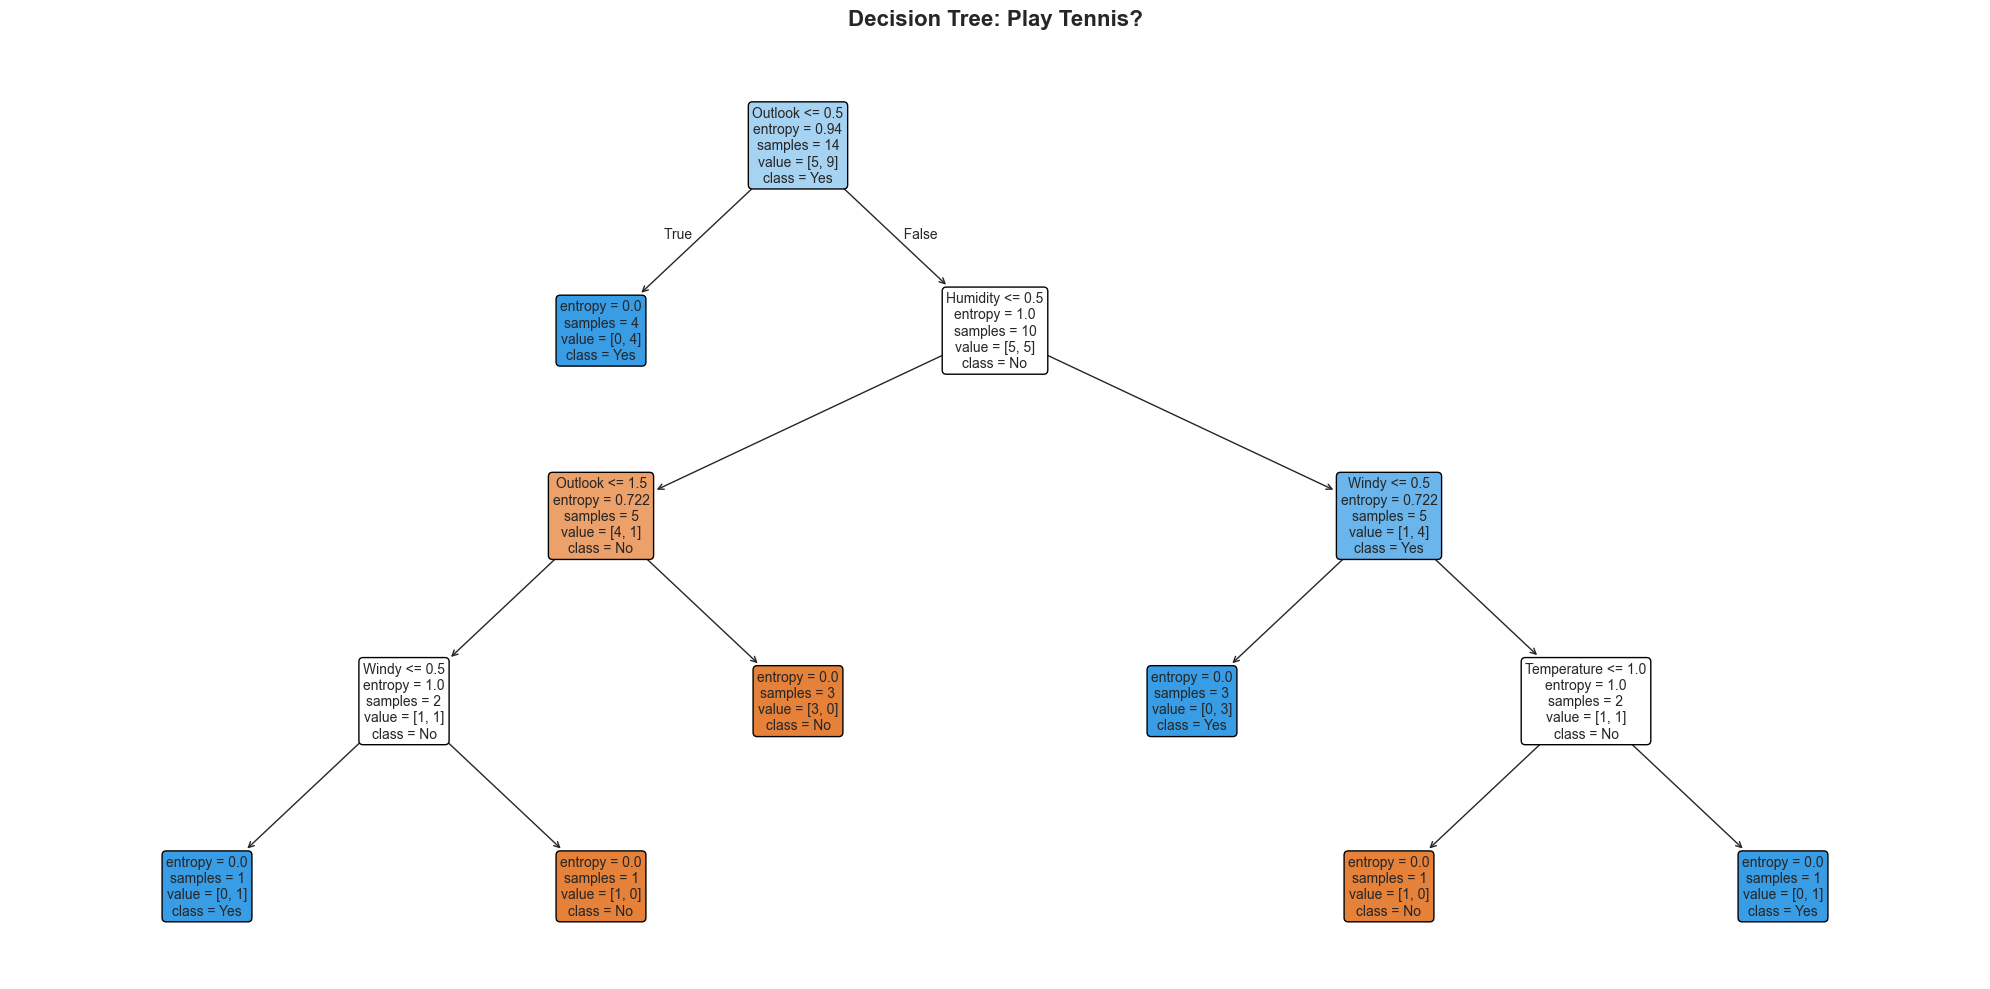


How to Read This Tree:
Each node shows:
  1. The split condition (e.g., 'Outlook <= 1.5')
  2. 'entropy' - the impurity at that node
  3. 'samples' - number of samples reaching that node
  4. 'value' - [count of No, count of Yes]
  5. 'class' - the majority class at that node

Colors:
  Orange: Predicts 'No'
  Blue: Predicts 'Yes'
  Darker color: Higher purity (more confident)


In [8]:
# Visualize using plot_tree
plt.figure(figsize=(20, 10))

plot_tree(dt_classifier, 
          feature_names=feature_columns,
          class_names=['No', 'Yes'],
          filled=True,              # Color nodes by class
          rounded=True,             # Rounded boxes
          fontsize=10)

plt.title('Decision Tree: Play Tennis?', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nHow to Read This Tree:")
print("="*80)
print("Each node shows:")
print("  1. The split condition (e.g., 'Outlook <= 1.5')")
print("  2. 'entropy' - the impurity at that node")
print("  3. 'samples' - number of samples reaching that node")
print("  4. 'value' - [count of No, count of Yes]")
print("  5. 'class' - the majority class at that node")
print("\nColors:")
print("  Orange: Predicts 'No'")
print("  Blue: Predicts 'Yes'")
print("  Darker color: Higher purity (more confident)")

### 2.2 Text Representation

In [9]:
# Export tree as text
tree_rules = export_text(dt_classifier, 
                         feature_names=feature_columns)

print("Decision Tree Rules (Text Format):")
print("="*80)
print(tree_rules)

print("\nReading the Rules:")
print("-" * 80)
print("- Each '|' represents a level in the tree")
print("- '<=' means 'less than or equal to'")
print("- 'class:' shows the predicted class at leaf nodes")
print("- Follow the path from root to leaf for a prediction")

Decision Tree Rules (Text Format):
|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Windy <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Windy >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Windy <= 0.50
|   |   |   |--- class: 1
|   |   |--- Windy >  0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1


Reading the Rules:
--------------------------------------------------------------------------------
- Each '|' represents a level in the tree
- '<=' means 'less than or equal to'
- 'class:' shows the predicted class at leaf nodes
- Follow the path from root to leaf for a prediction


### 2.3 Feature-Decision Mapping

Let's create a more readable version with actual feature values:

In [10]:
def get_decision_path_rules(tree, feature_names, class_names):
    """
    Extract human-readable decision rules from a tree.
    """
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]

    def recurse(node, depth, rules_so_far=""):
        indent = "  " * depth
        
        if tree_.feature[node] != -2:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            print(f"{indent}if {name} <= {threshold:.2f}:")
            recurse(tree_.children_left[node], depth + 1, 
                   rules_so_far + f"{name} <= {threshold:.2f} AND ")
            
            print(f"{indent}else:  # if {name} > {threshold:.2f}")
            recurse(tree_.children_right[node], depth + 1,
                   rules_so_far + f"{name} > {threshold:.2f} AND ")
        else:
            class_idx = np.argmax(tree_.value[node])
            class_label = class_names[class_idx]
            samples = tree_.n_node_samples[node]
            print(f"{indent}return '{class_label}' (samples: {samples})")

    recurse(0, 0)

print("\nDecision Tree Logic (Python-like code):")
print("="*80)
get_decision_path_rules(dt_classifier, feature_columns, ['No', 'Yes'])


Decision Tree Logic (Python-like code):
if Outlook <= 0.50:
  return 'Yes' (samples: 4)
else:  # if Outlook > 0.50
  if Humidity <= 0.50:
    if Outlook <= 1.50:
      if Windy <= 0.50:
        return 'Yes' (samples: 1)
      else:  # if Windy > 0.50
        return 'No' (samples: 1)
    else:  # if Outlook > 1.50
      return 'No' (samples: 3)
  else:  # if Humidity > 0.50
    if Windy <= 0.50:
      return 'Yes' (samples: 3)
    else:  # if Windy > 0.50
      if Temperature <= 1.00:
        return 'No' (samples: 1)
      else:  # if Temperature > 1.00
        return 'Yes' (samples: 1)


## 3. Understanding Tree Structure

Let's dive deeper into the tree's internal structure.

In [11]:
# Access tree structure
tree_structure = dt_classifier.tree_

print("Tree Structure Details:")
print("="*80)
print(f"Number of nodes: {tree_structure.node_count}")
print(f"Number of features: {tree_structure.n_features}")
print(f"Number of classes: {tree_structure.n_classes[0]}")
print(f"Number of outputs: {tree_structure.n_outputs}")

# Node-by-node analysis
print("\n" + "="*80)
print("Node-by-Node Analysis:")
print("="*80)

n_nodes = tree_structure.node_count
children_left = tree_structure.children_left
children_right = tree_structure.children_right
feature = tree_structure.feature
threshold = tree_structure.threshold
values = tree_structure.value

node_data = []

for i in range(n_nodes):
    is_leaf = children_left[i] == children_right[i]
    
    node_info = {
        'Node': i,
        'Type': 'Leaf' if is_leaf else 'Internal',
        'Feature': feature_columns[feature[i]] if not is_leaf else '-',
        'Threshold': f"{threshold[i]:.2f}" if not is_leaf else '-',
        'Samples': int(values[i].sum()),
        '[No, Yes]': f"[{int(values[i][0][0])}, {int(values[i][0][1])}]",
        'Prediction': 'Yes' if values[i][0][1] > values[i][0][0] else 'No'
    }
    node_data.append(node_info)

nodes_df = pd.DataFrame(node_data)
display(nodes_df)

Tree Structure Details:
Number of nodes: 13
Number of features: 4
Number of classes: 2
Number of outputs: 1

Node-by-Node Analysis:


,Node,Type,Feature,Threshold,Samples,"[No, Yes]",Prediction
0,0,Internal,Outlook,0.50,1,"[0, 0]",Yes
1,1,Leaf,-,-,1,"[0, 1]",Yes
2,2,Internal,Humidity,0.50,1,"[0, 0]",No
3,3,Internal,Outlook,1.50,1,"[0, 0]",No
4,4,Internal,Windy,0.50,1,"[0, 0]",No
5,5,Leaf,-,-,1,"[0, 1]",Yes
6,6,Leaf,-,-,1,"[1, 0]",No
7,7,Leaf,-,-,1,"[1, 0]",No
8,8,Internal,Windy,0.50,1,"[0, 0]",Yes
9,9,Leaf,-,-,1,"[0, 1]",Yes


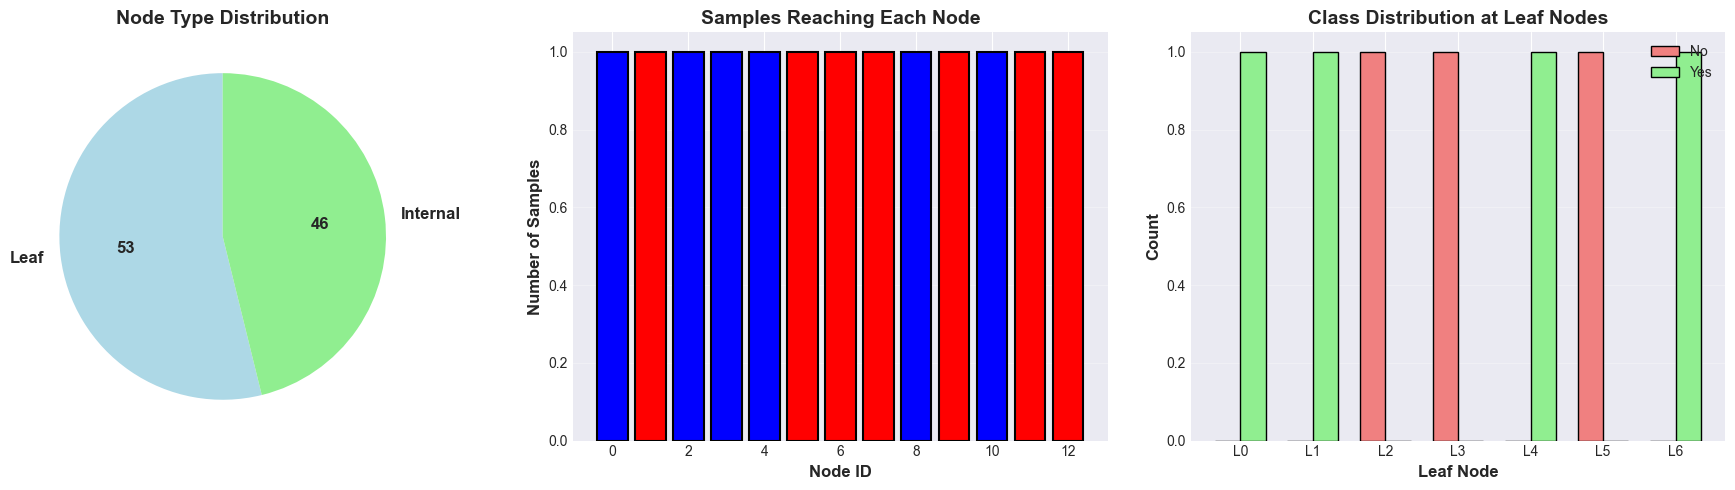

In [12]:
# Visualize node statistics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Node types
node_types = nodes_df['Type'].value_counts()
colors = ['lightblue', 'lightgreen']
axes[0].pie(node_types.values, labels=node_types.index, autopct='%d',
           colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Node Type Distribution', fontsize=14, fontweight='bold')

# Plot 2: Samples per node
axes[1].bar(nodes_df['Node'], nodes_df['Samples'], 
           color=['red' if t == 'Leaf' else 'blue' for t in nodes_df['Type']],
           edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Node ID', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[1].set_title('Samples Reaching Each Node', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Class distribution at leaves
leaf_nodes = nodes_df[nodes_df['Type'] == 'Leaf']
x = np.arange(len(leaf_nodes))
width = 0.35

# Extract No and Yes counts
no_counts = [int(s.split(',')[0].strip('[')) for s in leaf_nodes['[No, Yes]']]
yes_counts = [int(s.split(',')[1].strip(']')) for s in leaf_nodes['[No, Yes]']]

axes[2].bar(x - width/2, no_counts, width, label='No', color='lightcoral', edgecolor='black')
axes[2].bar(x + width/2, yes_counts, width, label='Yes', color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Leaf Node', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].set_title('Class Distribution at Leaf Nodes', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"L{i}" for i in range(len(leaf_nodes))])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. A More Complex Example: Iris Dataset

Now let's work with a more realistic dataset!

In [13]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create DataFrame for better visualization
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in y_iris]

print("Iris Dataset:")
print("="*80)
print(f"Shape: {iris_df.shape}")
print(f"\nFeatures: {list(iris.feature_names)}")
print(f"Classes: {list(iris.target_names)}")
print("\nFirst few rows:")
display(iris_df.head(10))

print("\nClass Distribution:")
print(iris_df['species'].value_counts())

Iris Dataset:
Shape: (150, 5)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First few rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa



Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


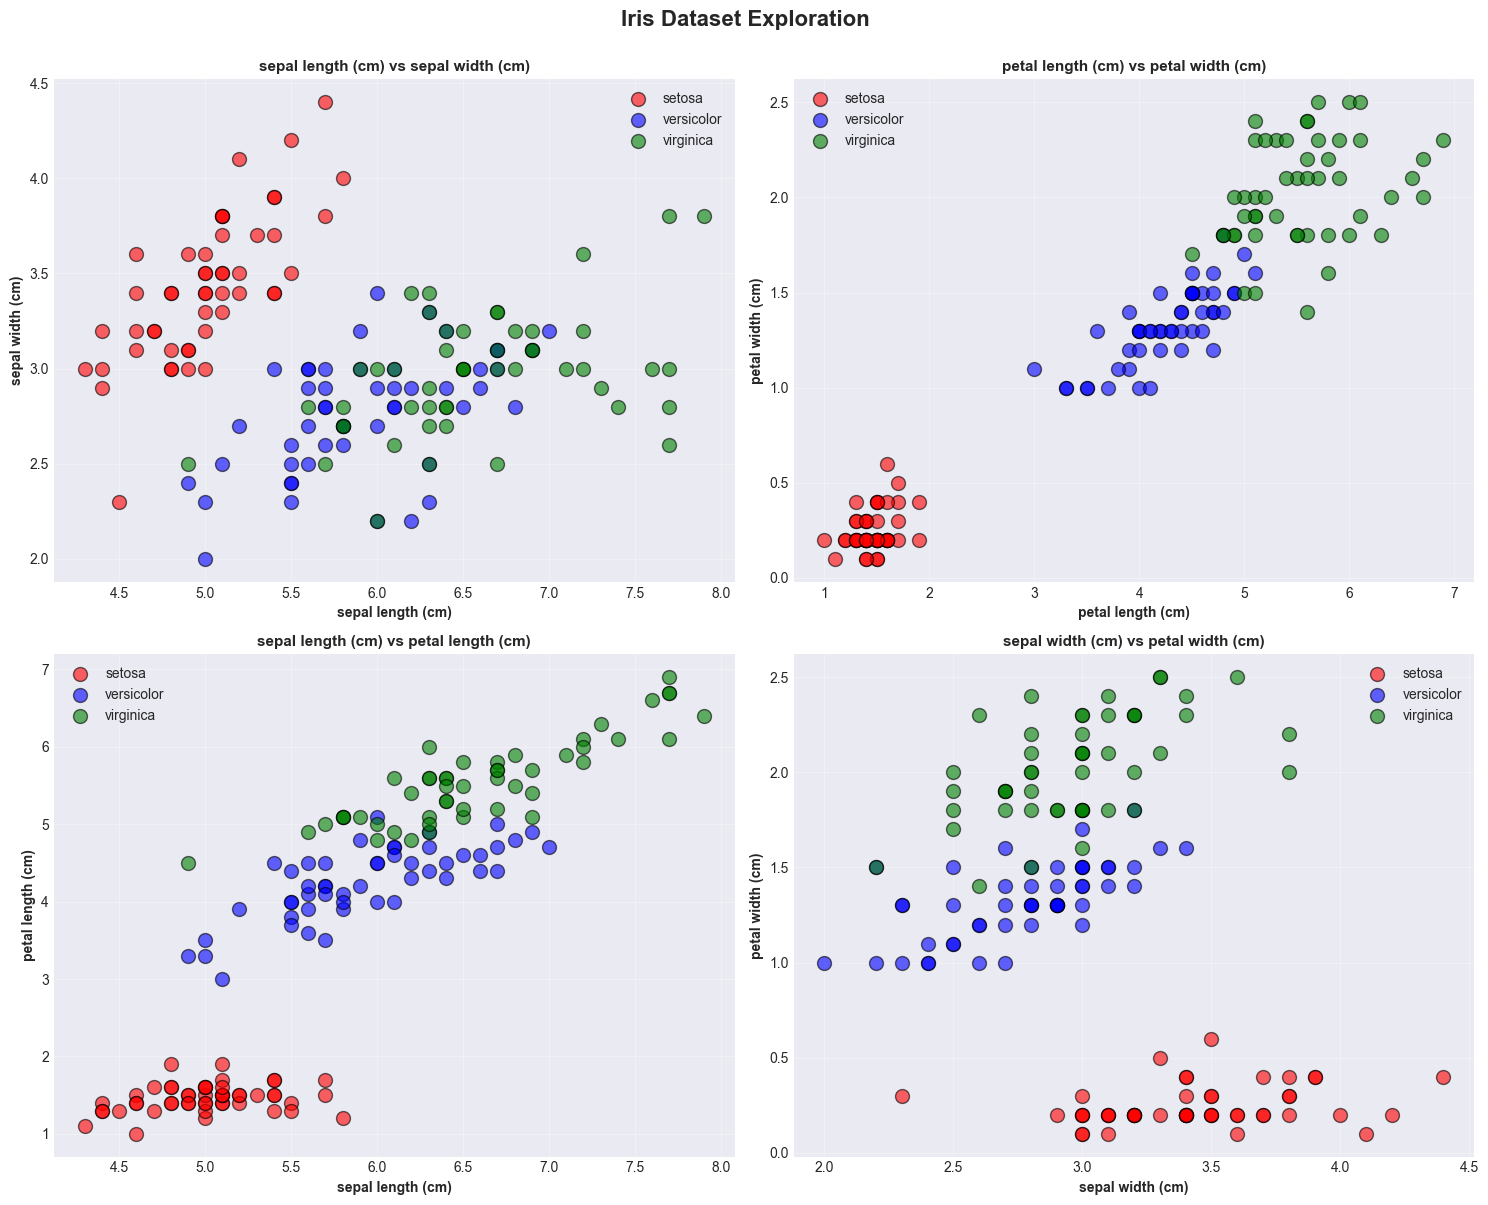

In [14]:
# Visualize the dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Iris Dataset Exploration', fontsize=16, fontweight='bold', y=1.00)

# Pairplot style for 2 feature combinations
feature_pairs = [
    ('sepal length (cm)', 'sepal width (cm)'),
    ('petal length (cm)', 'petal width (cm)'),
    ('sepal length (cm)', 'petal length (cm)'),
    ('sepal width (cm)', 'petal width (cm)')
]

colors_species = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

for idx, (ax, (feat1, feat2)) in enumerate(zip(axes.flat, feature_pairs)):
    for species in iris.target_names:
        species_data = iris_df[iris_df['species'] == species]
        ax.scatter(species_data[feat1], species_data[feat2], 
                  label=species, alpha=0.6, s=100, 
                  color=colors_species[species], edgecolors='black', linewidth=1)
    
    ax.set_xlabel(feat1, fontsize=10, fontweight='bold')
    ax.set_ylabel(feat2, fontsize=10, fontweight='bold')
    ax.set_title(f'{feat1} vs {feat2}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Train-Test Split

Let's properly split our data for training and testing:

In [15]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, 
    test_size=0.3,      # 30% for testing
    random_state=42,    # For reproducibility
    stratify=y_iris     # Maintain class proportions
)

print("Data Split:")
print("="*80)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Data Split:
Training set: 105 samples
Test set: 45 samples

Training set class distribution:
0    35
1    35
2    35
Name: count, dtype: int64

Test set class distribution:
0    15
1    15
2    15
Name: count, dtype: int64


### 4.2 Train Decision Tree on Iris

In [16]:
# Create and train decision tree
iris_tree = DecisionTreeClassifier(
    criterion='gini',         # Using Gini impurity this time
    random_state=42,
    max_depth=3              # Limit depth to avoid overfitting
)

# Train
iris_tree.fit(X_train, y_train)

# Evaluate on both sets
train_accuracy = iris_tree.score(X_train, y_train)
test_accuracy = iris_tree.score(X_test, y_test)

print("Model Training Complete!")
print("="*80)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"\nTree depth: {iris_tree.get_depth()}")
print(f"Number of leaves: {iris_tree.get_n_leaves()}")

Model Training Complete!
Training accuracy: 98.10%
Test accuracy: 97.78%

Tree depth: 3
Number of leaves: 5


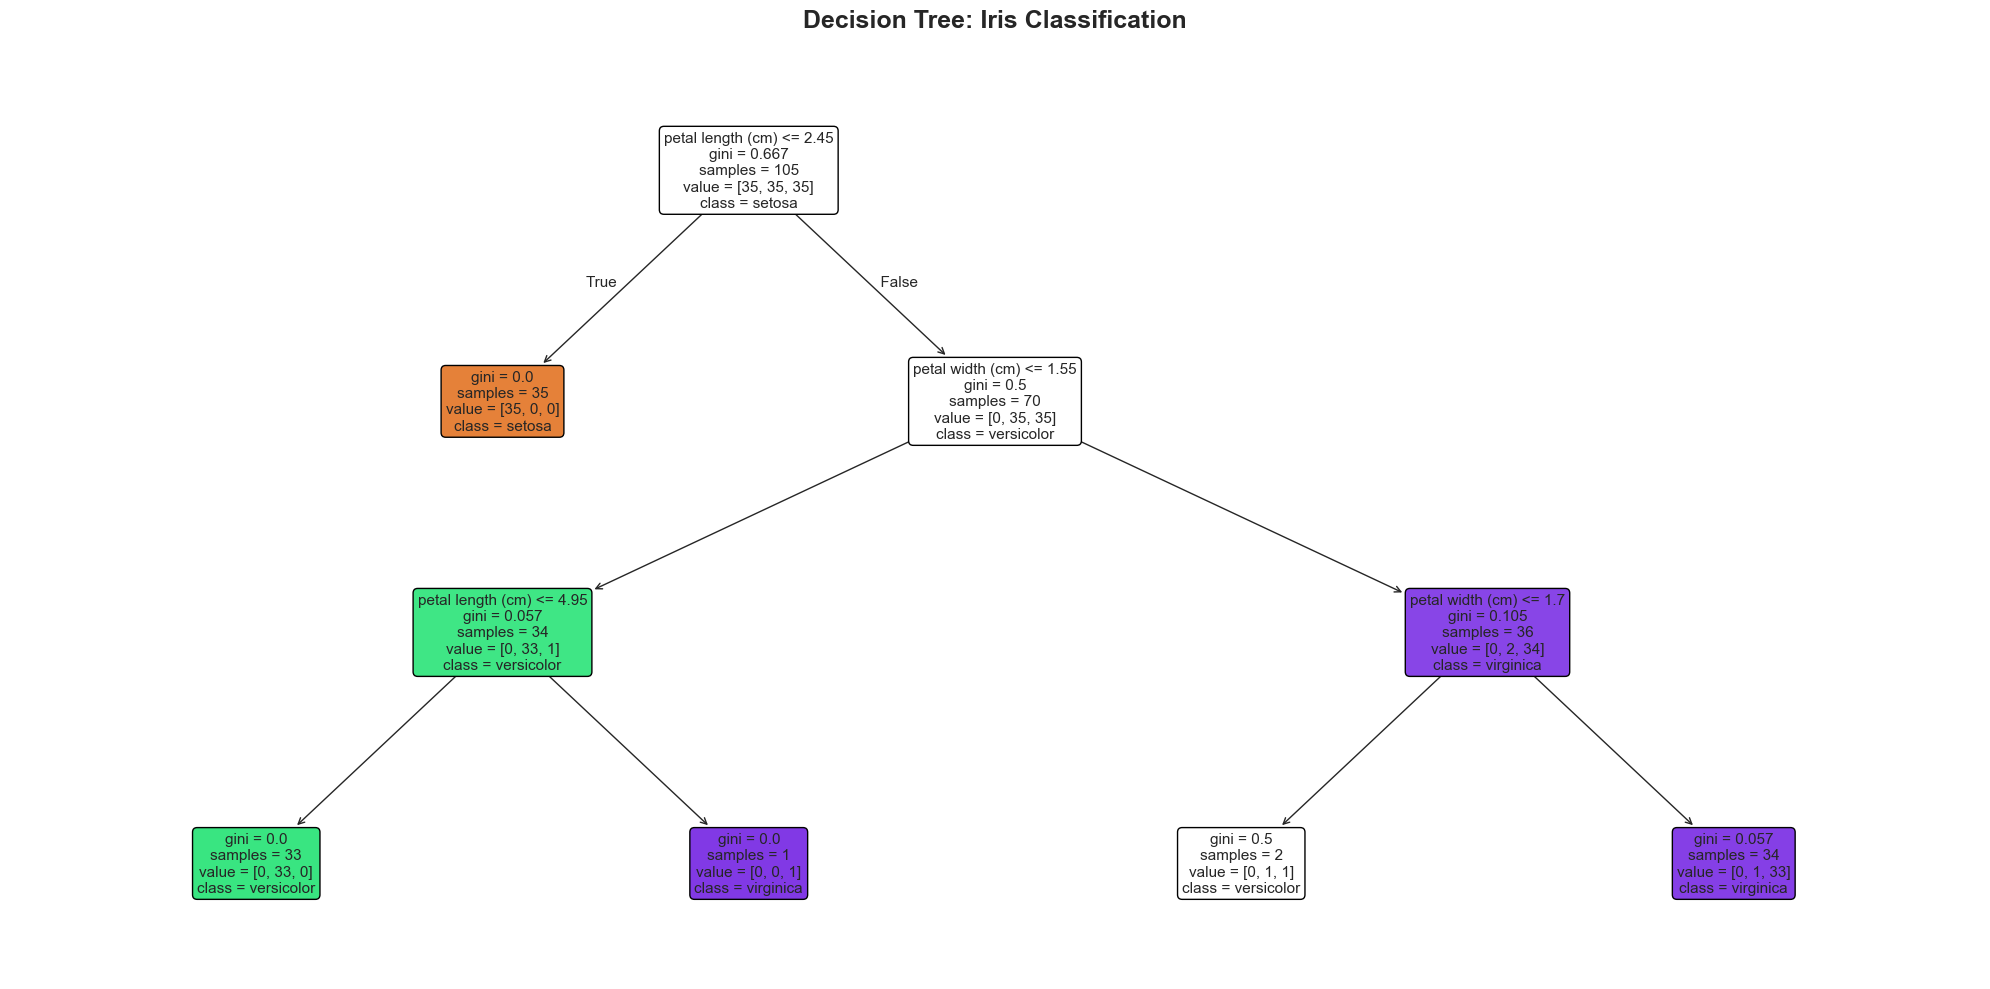

In [17]:
# Visualize the Iris tree
plt.figure(figsize=(20, 10))

plot_tree(iris_tree,
         feature_names=iris.feature_names,
         class_names=iris.target_names,
         filled=True,
         rounded=True,
         fontsize=11)

plt.title('Decision Tree: Iris Classification', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 4.3 Detailed Evaluation

Confusion Matrix (Test Set):
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


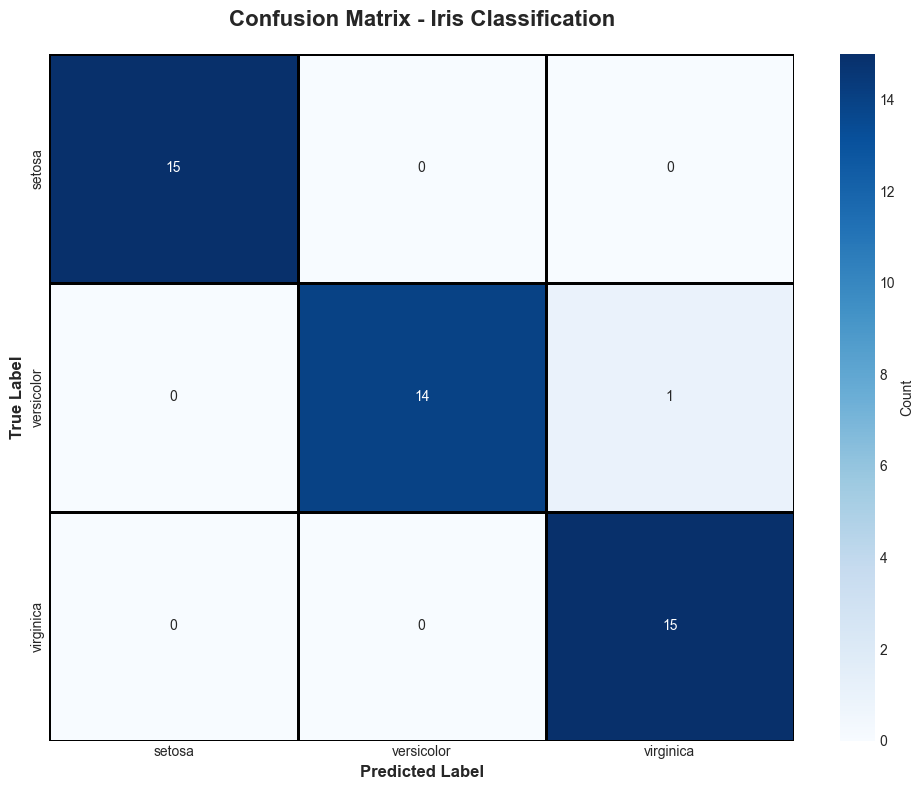


Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [18]:
# Make predictions
y_pred_train = iris_tree.predict(X_train)
y_pred_test = iris_tree.predict(X_test)

# Confusion Matrix
print("Confusion Matrix (Test Set):")
print("="*80)
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=iris.target_names,
           yticklabels=iris.target_names,
           cbar_kws={'label': 'Count'},
           linewidths=2, linecolor='black')
plt.title('Confusion Matrix - Iris Classification', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*80)
print("Classification Report (Test Set):")
print("="*80)
print(classification_report(y_test, y_pred_test, target_names=iris.target_names))

In [19]:
# Prediction probabilities
print("\nSample Predictions with Probabilities:")
print("="*80)

# Get predictions and probabilities for first 10 test samples
sample_predictions = iris_tree.predict(X_test[:10])
sample_probabilities = iris_tree.predict_proba(X_test[:10])

results = pd.DataFrame({
    'True': [iris.target_names[i] for i in y_test[:10]],
    'Predicted': [iris.target_names[i] for i in sample_predictions],
    'Prob_Setosa': [f"{p[0]*100:.1f}%" for p in sample_probabilities],
    'Prob_Versicolor': [f"{p[1]*100:.1f}%" for p in sample_probabilities],
    'Prob_Virginica': [f"{p[2]*100:.1f}%" for p in sample_probabilities],
    'Correct': ['✓' if y_test[i] == sample_predictions[i] else '✗' for i in range(10)]
})

display(results)


Sample Predictions with Probabilities:


,True,Predicted,Prob_Setosa,Prob_Versicolor,Prob_Virginica,Correct
0,virginica,virginica,0.0%,2.9%,97.1%,✓
1,versicolor,versicolor,0.0%,100.0%,0.0%,✓
2,virginica,virginica,0.0%,0.0%,100.0%,✓
3,versicolor,versicolor,0.0%,50.0%,50.0%,✓
4,virginica,virginica,0.0%,2.9%,97.1%,✓
5,virginica,virginica,0.0%,2.9%,97.1%,✓
6,versicolor,versicolor,0.0%,100.0%,0.0%,✓
7,versicolor,versicolor,0.0%,100.0%,0.0%,✓
8,setosa,setosa,100.0%,0.0%,0.0%,✓
9,virginica,virginica,0.0%,2.9%,97.1%,✓


## 5. Decision Boundaries Visualization

Let's visualize how the decision tree creates boundaries in feature space.

Decision Boundary Visualization:
Using only the first two features (sepal length and sepal width)
for 2D visualization.



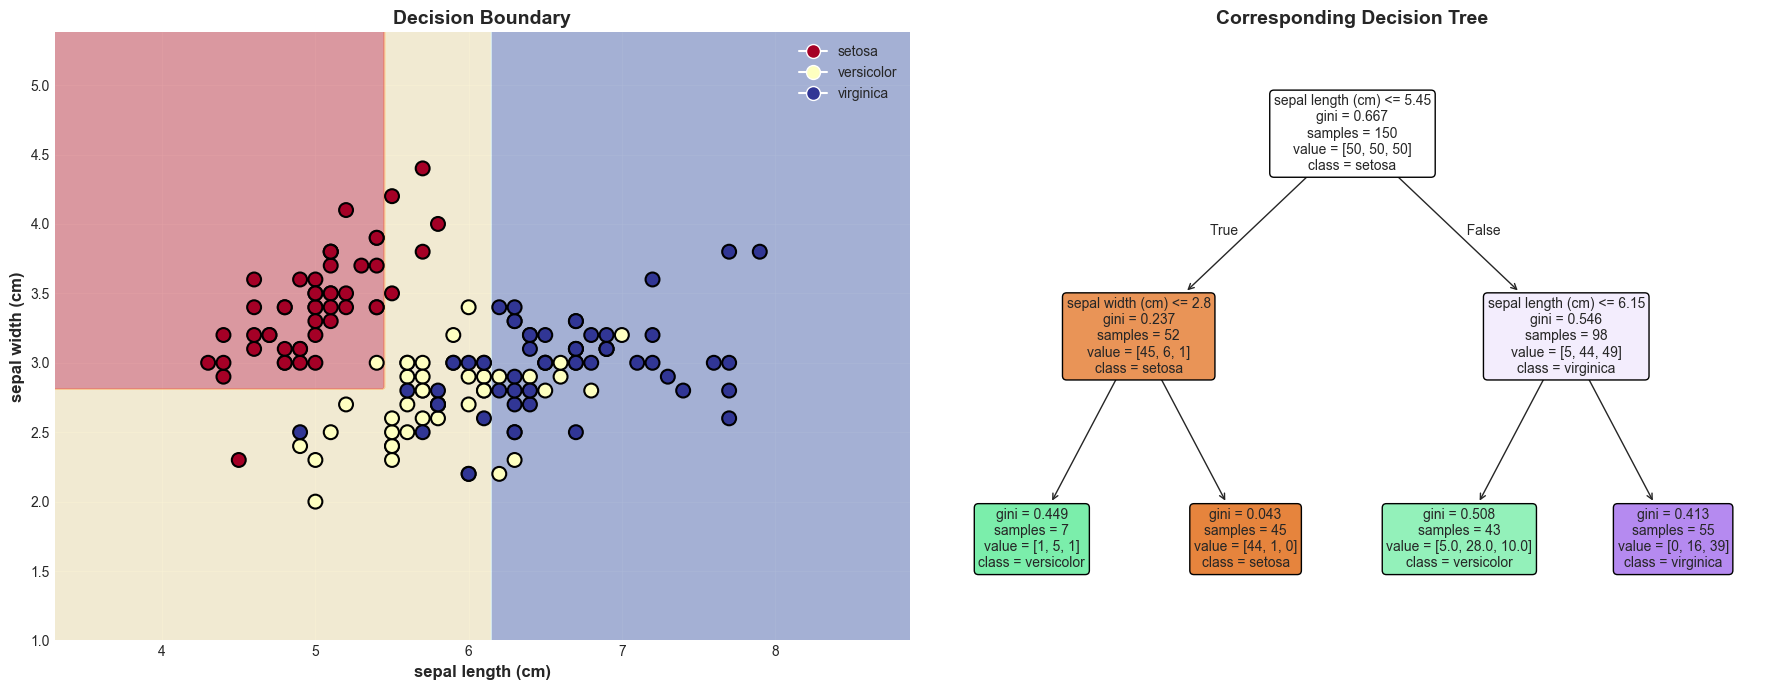


Notice:
1. Decision boundaries are axis-parallel (horizontal/vertical lines)
2. Each region corresponds to a leaf in the tree
3. The tree creates rectangular decision regions
4. More depth = more complex boundaries = more rectangles


In [20]:
def plot_decision_boundary(X, y, model, feature_names, class_names, resolution=0.02):
    """
    Plot decision boundary for a 2D classification problem.
    """
    # Use only first two features for visualization
    X_2d = X[:, :2]
    
    # Train model on 2D data
    model.fit(X_2d, y)
    
    # Create mesh
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                        np.arange(y_min, y_max, resolution))
    
    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Decision boundary plot
    ax1.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    scatter = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=y, 
                         cmap='RdYlBu', edgecolor='black', s=100, linewidth=1.5)
    ax1.set_xlabel(feature_names[0], fontsize=12, fontweight='bold')
    ax1.set_ylabel(feature_names[1], fontsize=12, fontweight='bold')
    ax1.set_title('Decision Boundary', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=scatter.cmap(scatter.norm(i)), 
                                 markersize=10, label=class_names[i])
                      for i in range(len(class_names))]
    ax1.legend(handles=legend_elements, loc='best')
    
    # Plot the tree
    plot_tree(model, feature_names=feature_names[:2], class_names=class_names,
             filled=True, rounded=True, ax=ax2, fontsize=10)
    ax2.set_title('Corresponding Decision Tree', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return model

# Create a shallow tree for better visualization
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=42)

print("Decision Boundary Visualization:")
print("="*80)
print("Using only the first two features (sepal length and sepal width)")
print("for 2D visualization.\n")

model_2d = plot_decision_boundary(X_iris, y_iris, shallow_tree, 
                                 iris.feature_names, iris.target_names)

print("\nNotice:")
print("1. Decision boundaries are axis-parallel (horizontal/vertical lines)")
print("2. Each region corresponds to a leaf in the tree")
print("3. The tree creates rectangular decision regions")
print("4. More depth = more complex boundaries = more rectangles")

### 5.2 Comparing Different Depths

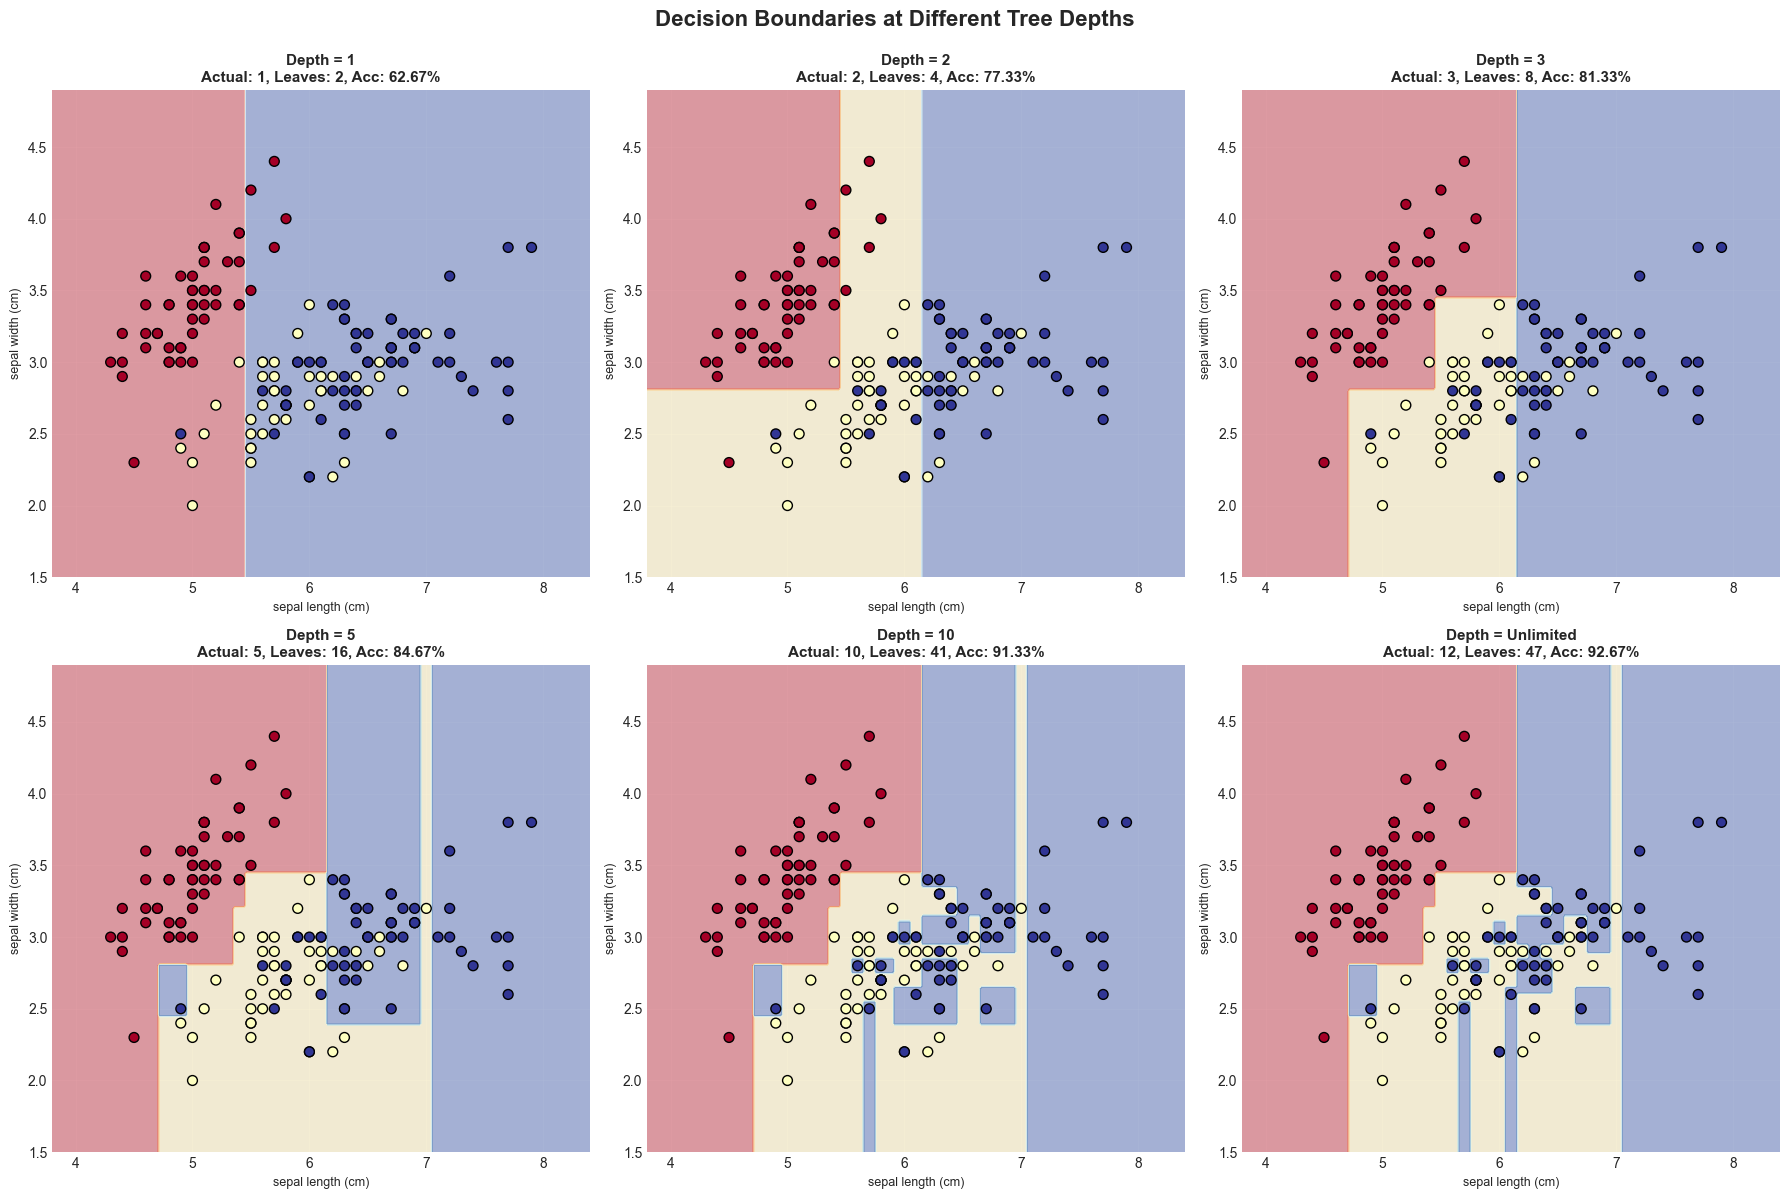


Observations:
1. Shallow trees (depth 1-2): Simple boundaries, may underfit
2. Medium trees (depth 3-5): Balance between simplicity and accuracy
3. Deep trees (depth 10+): Complex boundaries, may overfit
4. Unlimited depth: Perfect fit on training data (overfitting risk!)


In [21]:
# Compare trees of different depths
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Decision Boundaries at Different Tree Depths', 
            fontsize=16, fontweight='bold', y=0.995)

depths = [1, 2, 3, 5, 10, None]  # None means unlimited

for idx, (ax, depth) in enumerate(zip(axes.flat, depths)):
    # Train tree
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_iris[:, :2], y_iris)
    
    # Create mesh
    x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
    y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                        np.arange(y_min, y_max, 0.02))
    
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, 
              cmap='RdYlBu', edgecolor='black', s=50, linewidth=1)
    
    depth_label = f"Depth = {depth}" if depth is not None else "Depth = Unlimited"
    actual_depth = tree.get_depth()
    n_leaves = tree.get_n_leaves()
    accuracy = tree.score(X_iris[:, :2], y_iris)
    
    ax.set_title(f"{depth_label}\nActual: {actual_depth}, Leaves: {n_leaves}, Acc: {accuracy:.2%}",
                fontsize=11, fontweight='bold')
    ax.set_xlabel(iris.feature_names[0], fontsize=9)
    ax.set_ylabel(iris.feature_names[1], fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("="*80)
print("1. Shallow trees (depth 1-2): Simple boundaries, may underfit")
print("2. Medium trees (depth 3-5): Balance between simplicity and accuracy")
print("3. Deep trees (depth 10+): Complex boundaries, may overfit")
print("4. Unlimited depth: Perfect fit on training data (overfitting risk!)")

## 6. Interactive Example: Make Your Own Predictions

Let's create an interactive example where you can input features and get predictions!


Example 1: Typical Setosa

IRIS SPECIES PREDICTION

Input Features:
  Sepal Length: 5.1 cm
  Sepal Width:  3.5 cm
  Petal Length: 1.4 cm
  Petal Width:  0.2 cm

Prediction: ****************************************
  Species: SETOSA
****************************************

Class Probabilities:
  setosa      : 100.0% ██████████████████████████████████████████████████
  versicolor  :   0.0% 
  virginica   :   0.0% 

Most Similar Training Samples:
  1. setosa (distance: 0.00)
  2. setosa (distance: 0.10)
  3. setosa (distance: 0.14)


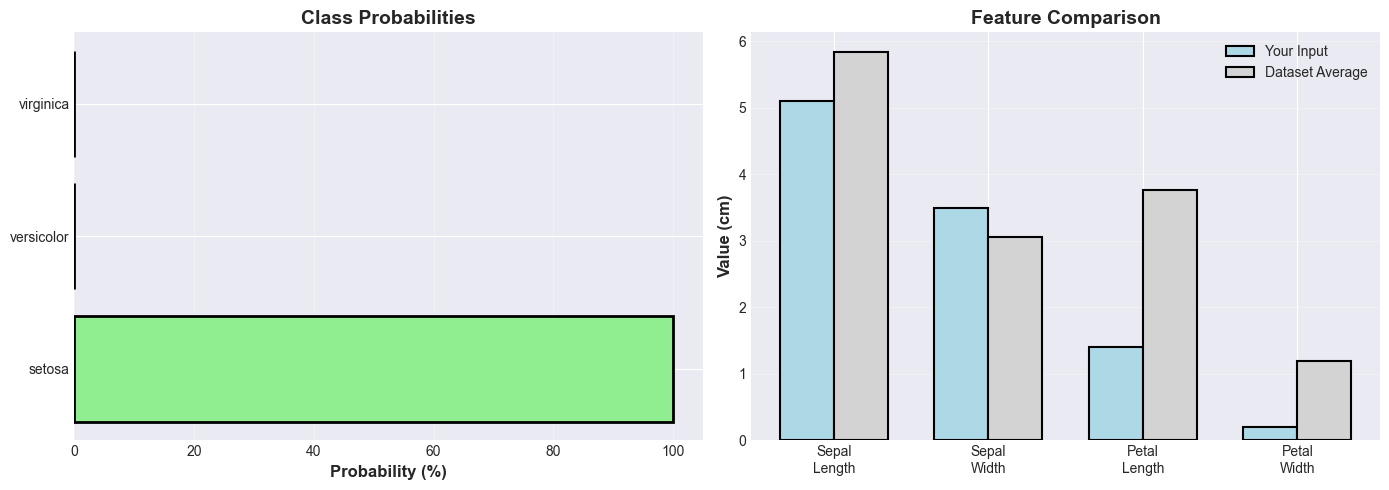

In [22]:
def predict_iris_interactive(sepal_length, sepal_width, petal_length, petal_width):
    """
    Make an interactive prediction for Iris classification.
    """
    # Create input array
    input_features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    
    # Make prediction
    prediction = iris_tree.predict(input_features)[0]
    probabilities = iris_tree.predict_proba(input_features)[0]
    
    # Display results
    print("\n" + "="*80)
    print("IRIS SPECIES PREDICTION")
    print("="*80)
    
    print("\nInput Features:")
    print(f"  Sepal Length: {sepal_length} cm")
    print(f"  Sepal Width:  {sepal_width} cm")
    print(f"  Petal Length: {petal_length} cm")
    print(f"  Petal Width:  {petal_width} cm")
    
    print("\nPrediction: " + "*" * 40)
    print(f"  Species: {iris.target_names[prediction].upper()}")
    print("*" * 40)
    
    print("\nClass Probabilities:")
    for i, (species, prob) in enumerate(zip(iris.target_names, probabilities)):
        bar = "█" * int(prob * 50)
        print(f"  {species:12s}: {prob*100:5.1f}% {bar}")
    
    # Show similar samples from training data
    distances = np.linalg.norm(X_train - input_features, axis=1)
    closest_indices = np.argsort(distances)[:3]
    
    print("\nMost Similar Training Samples:")
    for i, idx in enumerate(closest_indices, 1):
        similar_species = iris.target_names[y_train[idx]]
        print(f"  {i}. {similar_species} (distance: {distances[idx]:.2f})")
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Probability bar chart
    colors_prob = ['lightcoral' if i != prediction else 'lightgreen' 
                   for i in range(3)]
    ax1.barh(iris.target_names, probabilities * 100, color=colors_prob, 
            edgecolor='black', linewidth=2)
    ax1.set_xlabel('Probability (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Class Probabilities', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Feature comparison
    feature_names_short = ['Sepal\nLength', 'Sepal\nWidth', 'Petal\nLength', 'Petal\nWidth']
    input_vals = [sepal_length, sepal_width, petal_length, petal_width]
    mean_vals = X_iris.mean(axis=0)
    
    x = np.arange(len(feature_names_short))
    width = 0.35
    
    ax2.bar(x - width/2, input_vals, width, label='Your Input', 
           color='lightblue', edgecolor='black', linewidth=1.5)
    ax2.bar(x + width/2, mean_vals, width, label='Dataset Average', 
           color='lightgray', edgecolor='black', linewidth=1.5)
    
    ax2.set_ylabel('Value (cm)', fontsize=12, fontweight='bold')
    ax2.set_title('Feature Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(feature_names_short)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Example predictions
print("\nExample 1: Typical Setosa")
predict_iris_interactive(5.1, 3.5, 1.4, 0.2)


Example 2: Typical Versicolor

IRIS SPECIES PREDICTION

Input Features:
  Sepal Length: 5.9 cm
  Sepal Width:  3.0 cm
  Petal Length: 4.2 cm
  Petal Width:  1.5 cm

Prediction: ****************************************
  Species: VERSICOLOR
****************************************

Class Probabilities:
  setosa      :   0.0% 
  versicolor  : 100.0% ██████████████████████████████████████████████████
  virginica   :   0.0% 

Most Similar Training Samples:
  1. versicolor (distance: 0.00)
  2. versicolor (distance: 0.30)
  3. versicolor (distance: 0.33)


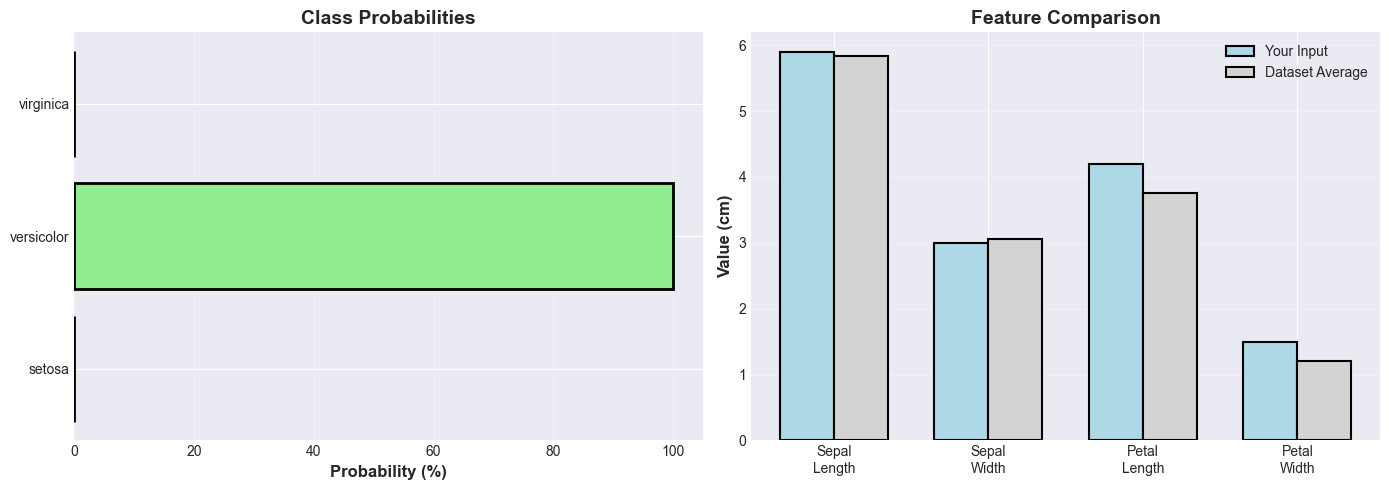

In [23]:
print("\nExample 2: Typical Versicolor")
predict_iris_interactive(5.9, 3.0, 4.2, 1.5)


Example 3: Typical Virginica

IRIS SPECIES PREDICTION

Input Features:
  Sepal Length: 6.5 cm
  Sepal Width:  3.0 cm
  Petal Length: 5.5 cm
  Petal Width:  2.0 cm

Prediction: ****************************************
  Species: VIRGINICA
****************************************

Class Probabilities:
  setosa      :   0.0% 
  versicolor  :   2.9% █
  virginica   :  97.1% ████████████████████████████████████████████████

Most Similar Training Samples:
  1. virginica (distance: 0.24)
  2. virginica (distance: 0.26)
  3. virginica (distance: 0.32)


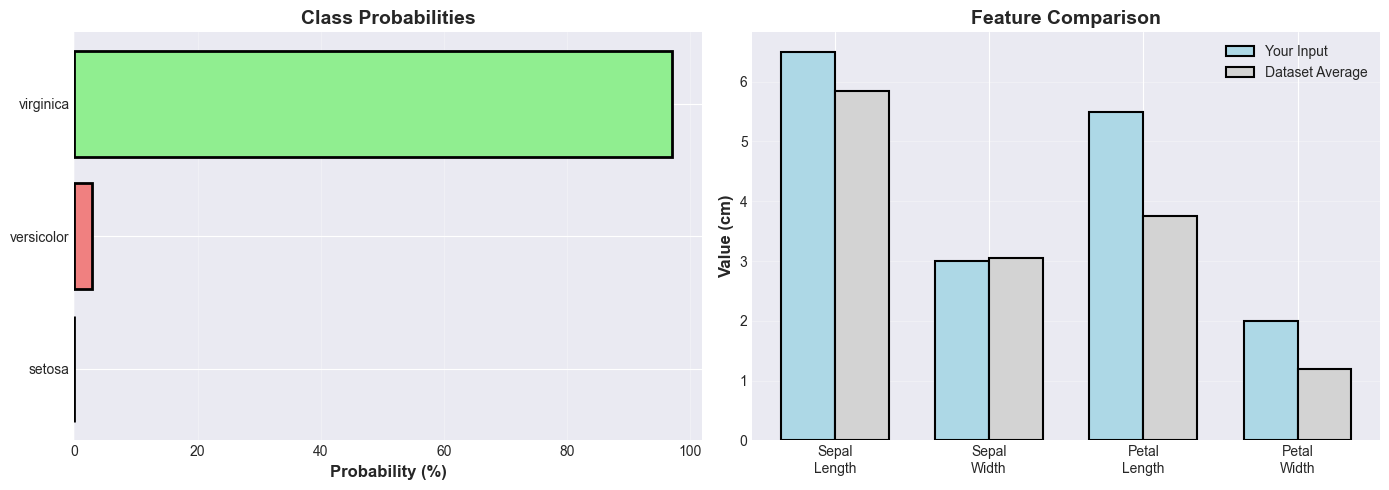

In [24]:
print("\nExample 3: Typical Virginica")
predict_iris_interactive(6.5, 3.0, 5.5, 2.0)


Try Your Own Prediction:
Modify the values below and run the cell to make your own prediction!


IRIS SPECIES PREDICTION

Input Features:
  Sepal Length: 6.0 cm
  Sepal Width:  2.8 cm
  Petal Length: 4.5 cm
  Petal Width:  1.5 cm

Prediction: ****************************************
  Species: VERSICOLOR
****************************************

Class Probabilities:
  setosa      :   0.0% 
  versicolor  : 100.0% ██████████████████████████████████████████████████
  virginica   :   0.0% 

Most Similar Training Samples:
  1. versicolor (distance: 0.10)
  2. versicolor (distance: 0.26)
  3. versicolor (distance: 0.37)


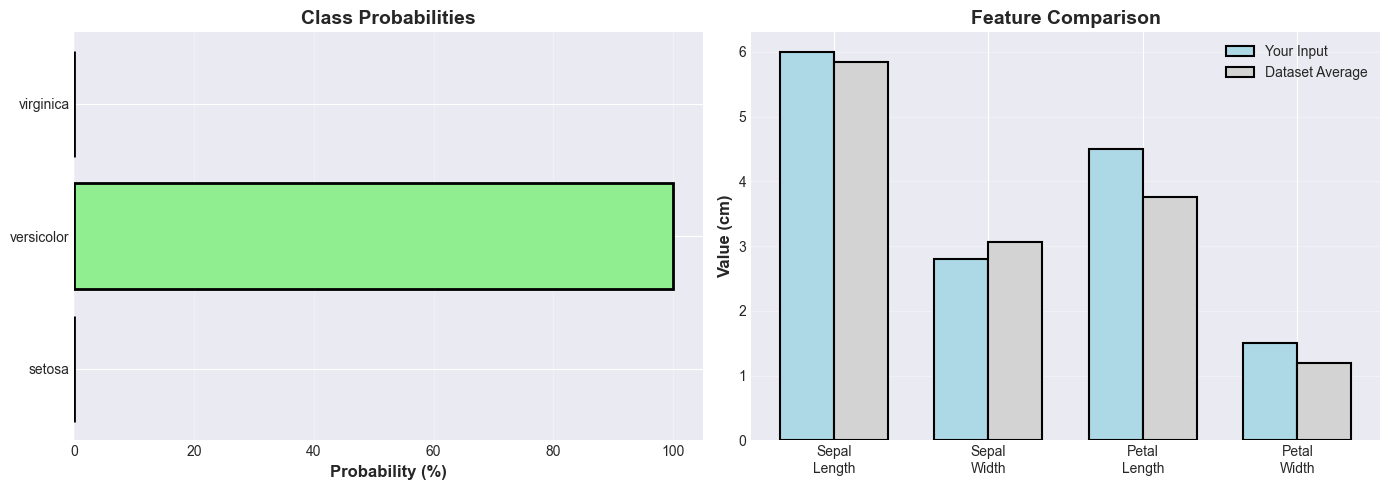

In [25]:
# Now try your own values!
print("\nTry Your Own Prediction:")
print("="*80)
print("Modify the values below and run the cell to make your own prediction!\n")

# MODIFY THESE VALUES:
my_sepal_length = 6.0
my_sepal_width = 2.8
my_petal_length = 4.5
my_petal_width = 1.5

predict_iris_interactive(my_sepal_length, my_sepal_width, my_petal_length, my_petal_width)

## 7. Summary and Key Takeaways

### What We Learned:

1. **Building Trees**: Use `DecisionTreeClassifier` from sklearn
   ```python
   tree = DecisionTreeClassifier(criterion='gini', max_depth=3)
   tree.fit(X_train, y_train)
   ```

2. **Visualization**: Multiple ways to visualize trees
   - `plot_tree()`: Visual tree diagram
   - `export_text()`: Text representation
   - `export_graphviz()`: High-quality graphics

3. **Predictions**: Get both classes and probabilities
   ```python
   predictions = tree.predict(X_test)
   probabilities = tree.predict_proba(X_test)
   ```

4. **Tree Structure**: Access internal nodes, features, thresholds

5. **Decision Boundaries**: Trees create rectangular (axis-parallel) regions

6. **Depth Impact**: 
   - Shallow: Simple, may underfit
   - Deep: Complex, may overfit
   - Need to find the right balance!

### Best Practices:

1. Always split data into train/test sets
2. Start with limited depth to avoid overfitting
3. Visualize the tree to understand decisions
4. Check both training and test accuracy
5. Use stratified splitting for imbalanced datasets

### Next Steps:

In **Session 15**, we'll learn about:
- Overfitting in decision trees
- Pruning techniques
- Hyperparameter tuning
- Feature importance

## 8. Practice Exercises

### Exercise 1: Build a Tree
Create a decision tree for the Tennis dataset using Gini impurity instead of entropy. Compare the results.

In [26]:
# Your code here


### Exercise 2: Feature Analysis
Using the Iris dataset, which two features would give the best decision boundary? Test different pairs.

In [27]:
# Your code here


### Exercise 3: Depth Experiment
Train trees with depths 1, 3, 5, 10, and unlimited on Iris. Record train and test accuracy for each. What do you observe?

In [28]:
# Your code here


### Exercise 4: Real Dataset
Load the breast cancer dataset from sklearn (`load_breast_cancer()`) and build a decision tree classifier. Evaluate its performance.

In [29]:
# Your code here


## Congratulations!

You've completed Session 14 on Decision Trees Implementation. You now know how to:
- Build decision tree models with sklearn
- Visualize trees in multiple ways
- Make and interpret predictions
- Understand decision boundaries

Next session: **Pruning and preventing overfitting!**